# Task 5: Detecting Data Leakage and Evaluation Issues

This notebook addresses the flaws detected in the original modelling pipeline (`task5_pipeline.py`) and implements the corrected methodology.

## Issues Identified in the Original Pipeline:
1. **Data Leakage:** The original script applied `StandardScaler` to the entire feature set `X` before performing the `train_test_split`. This inadvertently leaked information from the test set into the model training phase via the feature scaling process.
2. **Preprocessing Steps:**
    - The pipeline fails to handle categorical features. Calling standard scaling on strings will cause an error unless encoded using `OneHotEncoder` or similar.
    - The `id` column is included as a feature which is merely an arbitrary identifier and offers no predictive capabilities.
    - The script sourced an incorrect raw file (`airline_passenger_satisfaction_full.csv` instead of `antigravity_clean.csv`).
3. **Evaluation Methodology:**
    - The pipeline only checked `accuracy_score`. In classification evaluation, accuracy can be misinformative, specially for imbalanced data. A holistic evaluation encompasses Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix.


## Imports and Setup
We initialize necessary libraries and the `save_and_show` utility for figure rendering. We also set our working directory explicitly to the project root.

In [1]:
import os
# Change directory to project root to align with relative path rules
if os.getcwd().endswith("task5"):
    os.chdir("../../")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

# Create figures directory if it doesn't exist
os.makedirs("figures/antigravity", exist_ok=True)

figure_counter = 1
def save_and_show(fig, filename_base):
    global figure_counter
    filepath = f"figures/antigravity/{figure_counter:02d}_{filename_base}.png"
    fig.savefig(filepath, bbox_inches='tight', dpi=300)
    print(f"Figure saved to {filepath}")
    plt.show()
    figure_counter += 1


## Data Loading and Preprocessing Preparations
We load the proper dataset (`antigravity_clean.csv`), clean unused fields like `id`, and separate features (X) from the target (y).

In [2]:
# Load dataset
df = pd.read_csv("data/processed/antigravity_clean.csv")

# Drop the 'id' column as it has no predictive power
if "id" in df.columns:
    df = df.drop("id", axis=1)

# Handle potential missing values (if any)
df = df.dropna()

# Separate features and target
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

# Encode the target variable for ROC AUC evaluation
le = LabelEncoder()
y = le.fit_transform(y)


## Creating the Robust Preprocessing Pipeline
We use a `ColumnTransformer` to split categorical and numerical columns, applying `OneHotEncoder` and `StandardScaler` appropriately. Note that scaling happens accurately as part of this pipeline ensuring zero data leakage.

In [3]:
# Identify numerical and categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Create preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

# Create a full pipeline that includes preprocessing and the model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])


## Train Test Split & Model Fitting
The golden rule explicitly implemented here bounds the test data entirely separate prior to transformation via the `train_test_split`.

In [4]:
# Perform train/test split BEFORE preprocessing to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Train the model (pipeline handles fitting preprocessor on train data only)
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Flight Distance',
                                                   'Inflight wifi service',
                                                   'Departure/Arrival time '
                                                   'convenient',
                                                   'Ease of Online booking',
                                                   'Gate location',
                                                   'Food and drink',
                                                   'Online boarding',
                                                   'Seat comfort',
                                                   'Inflight entertainment',
                                                   'On-board service',
                                                   'Leg room service',
                                                   'Baggage handling',
                                                   'Checkin service',
                                                   'Inflight service',
                                                   'Cleanliness',
                                                   'Departure Delay in Minutes',
                                                   'Arrival Delay in Minutes']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Gender', 'Customer Type',
                                                   'Type of Travel',
                                                   'Class'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

## Evaluation Strategy
We evaluate the model computing holistic metrics including Precision, Recall, F1, and building the ROC Curve.

Classification Report:
                         precision    recall  f1-score   support

neutral or dissatisfied       0.88      0.90      0.89     18371
              satisfied       0.87      0.84      0.85     14001

               accuracy                           0.87     32372
              macro avg       0.87      0.87      0.87     32372
           weighted avg       0.87      0.87      0.87     32372

ROC AUC Score: 0.9252
Figure saved to figures/antigravity/01_roc_curve.png


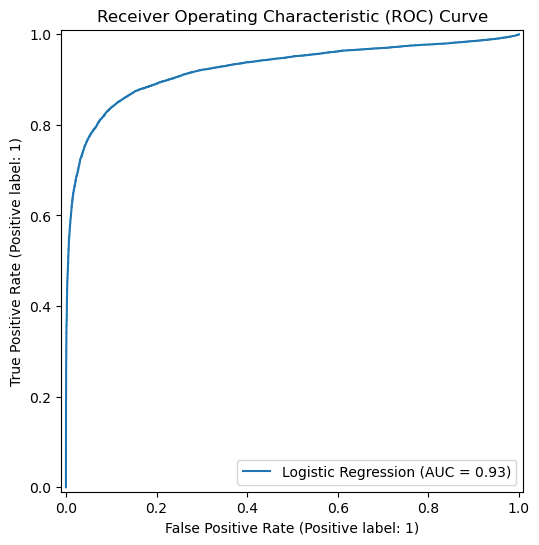

In [5]:
# Evaluate the model
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot and save ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name='Logistic Regression')
ax.set_title("Receiver Operating Characteristic (ROC) Curve")
save_and_show(fig, "roc_curve")
